In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
DATA_PATH = "Datasets/TCGA Dataset Splits"

X_train_unpurified = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test_unpurified  = pd.read_csv(f"{DATA_PATH}/X_test.csv")

DATA_PATH = "Datasets/TCGA InfiniumPurify Dataset Splits"

X_train_purified = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test_purified  = pd.read_csv(f"{DATA_PATH}/X_test.csv")

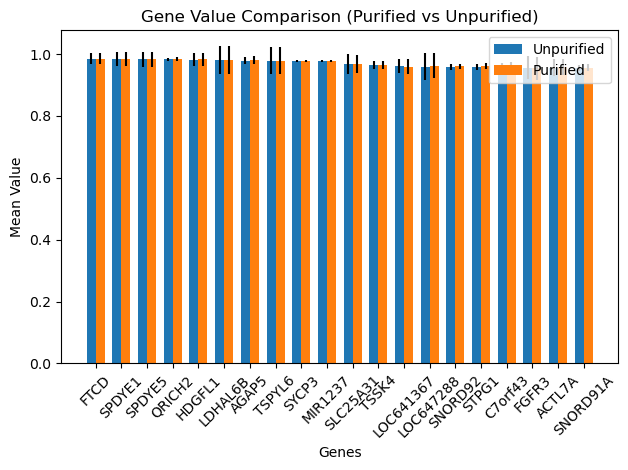

In [10]:
# Combine train + test for both datasets
X_unpurified = pd.concat([X_train_unpurified, X_test_unpurified])
X_purified   = pd.concat([X_train_purified, X_test_purified])

# Compute mean and std per gene
mean_unpurified = X_unpurified.mean()
std_unpurified  = X_unpurified.std()

mean_purified = X_purified.mean()
std_purified  = X_purified.std()

# Optional: select top N genes (important, otherwise too crowded)
top_n = 20
top_genes = mean_unpurified.sort_values(ascending=False).head(top_n).index

# Filter
mean_unpurified = mean_unpurified[top_genes]
std_unpurified  = std_unpurified[top_genes]

mean_purified = mean_purified[top_genes]
std_purified  = std_purified[top_genes]

# Plot
x = np.arange(len(top_genes))
width = 0.35

plt.figure()

plt.bar(x - width/2, mean_unpurified, width, yerr=std_unpurified, label='Unpurified')
plt.bar(x + width/2, mean_purified, width, yerr=std_purified, label='Purified')

plt.xticks(x, top_genes, rotation=45)
plt.xlabel("Genes")
plt.ylabel("Mean Value")
plt.title("Gene Value Comparison (Purified vs Unpurified)")
plt.legend()

plt.tight_layout()
plt.show()

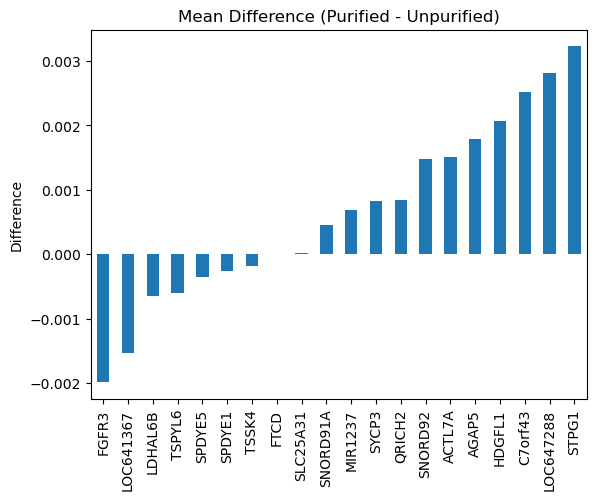

In [11]:
mean_diff = mean_purified - mean_unpurified

mean_diff.sort_values().plot(kind='bar')
plt.title("Mean Difference (Purified - Unpurified)")
plt.ylabel("Difference")
plt.show()

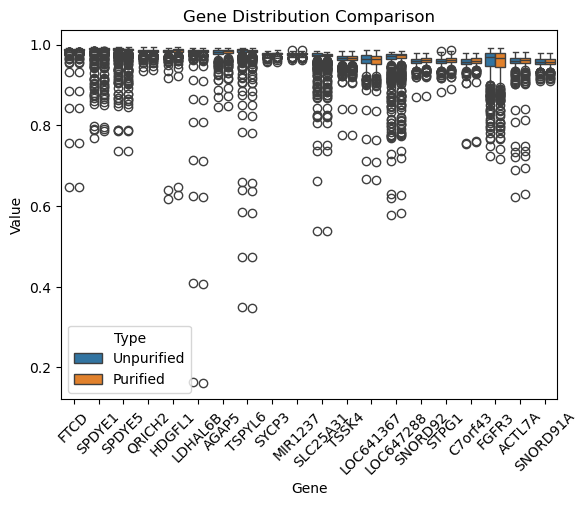

In [12]:
import seaborn as sns

# reshape data
df_un = X_unpurified[top_genes].melt(var_name='Gene', value_name='Value')
df_un['Type'] = 'Unpurified'

df_pur = X_purified[top_genes].melt(var_name='Gene', value_name='Value')
df_pur['Type'] = 'Purified'

df_all = pd.concat([df_un, df_pur])

plt.figure()
sns.boxplot(data=df_all, x='Gene', y='Value', hue='Type')
plt.xticks(rotation=45)
plt.title("Gene Distribution Comparison")
plt.show()

<Figure size 640x480 with 0 Axes>

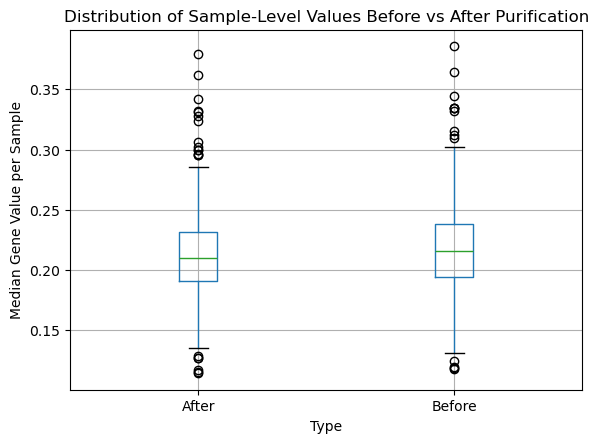

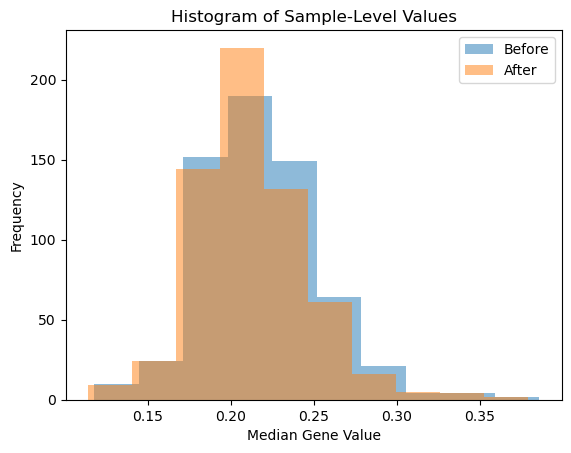

              Mean_Before  Mean_After  Difference
KLKB1            0.257492    0.134700   -0.122792
CMYA5            0.293213    0.185156   -0.108057
GRAMD1B          0.421603    0.316343   -0.105261
LOC100130776     0.337223    0.237027   -0.100195
PPP2R3A          0.403285    0.304902   -0.098383
GALNTL2          0.441428    0.343539   -0.097890
STX19            0.457408    0.361038   -0.096370
FAM196B          0.461075    0.366030   -0.095045
VWA3A            0.330133    0.236005   -0.094127
CST7             0.607438    0.703076    0.095638
NCR3             0.632747    0.728582    0.095835
S1PR4            0.639588    0.736620    0.097032
MIR142           0.720098    0.818056    0.097958
FERMT3           0.667189    0.766162    0.098974
GRAP2            0.728278    0.830319    0.102042
EVL              0.682038    0.784620    0.102582
MYO1G            0.735041    0.838252    0.103212
CXCR3            0.617332    0.721176    0.103845
LOC283663        0.548135    0.655121    0.106987


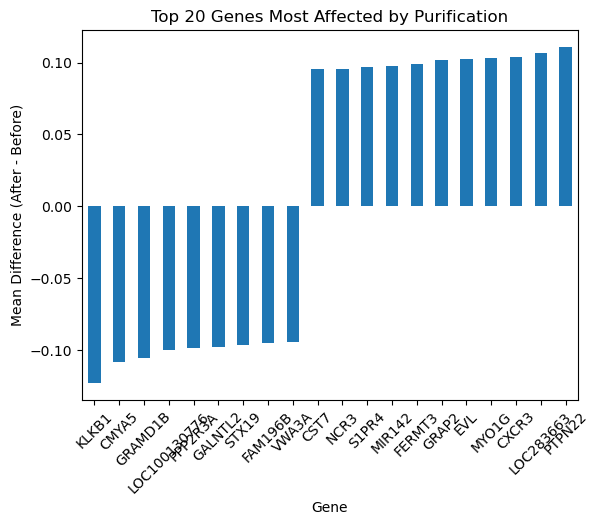

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========================
# STEP 1: Combine datasets
# ========================
X_unpurified = pd.concat([X_train_unpurified, X_test_unpurified], axis=0).reset_index(drop=True)
X_purified   = pd.concat([X_train_purified, X_test_purified], axis=0).reset_index(drop=True)

# ========================
# STEP 2: Sample-level summary
# ========================
sample_before = X_unpurified.median(axis=1)
sample_after  = X_purified.median(axis=1)

# ========================
# FIGURE 1: Boxplot (MAIN)
# ========================
df = pd.DataFrame({
    'Value': np.concatenate([sample_before, sample_after]),
    'Type': ['Before']*len(sample_before) + ['After']*len(sample_after)
})

plt.figure()
df.boxplot(by='Type', column='Value')
plt.title("Distribution of Sample-Level Values Before vs After Purification")
plt.suptitle("")
plt.ylabel("Median Gene Value per Sample")
plt.show()

# ========================
# FIGURE 2: Histogram
# ========================
plt.figure()
plt.hist(sample_before, alpha=0.5, label='Before')
plt.hist(sample_after, alpha=0.5, label='After')
plt.legend()
plt.title("Histogram of Sample-Level Values")
plt.xlabel("Median Gene Value")
plt.ylabel("Frequency")
plt.show()

# ========================
# STEP 3: Gene-level comparison
# ========================
mean_before = X_unpurified.mean(axis=0)
mean_after  = X_purified.mean(axis=0)

gene_diff = mean_after - mean_before

# ========================
# FIGURE 3: Top changing genes
# ========================
top_genes = gene_diff.abs().sort_values(ascending=False).head(20).index

# Create a table of results
top_table = pd.DataFrame({
    'Mean_Before': mean_before[top_genes],
    'Mean_After': mean_after[top_genes],
    'Difference': gene_diff[top_genes]
})

# Sort for readability
top_table = top_table.sort_values(by='Difference')

print(top_table)

plt.figure()
gene_diff[top_genes].sort_values().plot(kind='bar')

plt.title("Top 20 Genes Most Affected by Purification")
plt.ylabel("Mean Difference (After - Before)")
plt.xlabel("Gene")

plt.xticks(rotation=45)
plt.show()